**Task 2 - Implementing LSTM for Time-Series Forecasting**


***Read the following descriptions and instructions***

Time-series forecasting is a crucial task in various fields, including finance, economics, and weather prediction. In this question, you'll work with Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN) that is particularly effective at learning from sequences of data. LSTMs are designed to capture long-term dependencies in time-series data, making them well-suited for predicting future values based on historical patterns.

In this task, you will implement an LSTM model to forecast stock prices using historical data. Specifically, you'll use the closing prices of a stock to predict future prices, which is a common real-world application of time-series analysis in financial markets. This exercise will help you understand the principles of sequence modeling and how LSTMs can be applied to complex prediction tasks.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# 1. Load and Preprocess the Data
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df['Close'].values  # Use the 'Close' price for prediction

In [3]:
# 2. Prepare the Dataset for LSTM
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

In [7]:
# Load Data
file_path = '/content/drive/My Drive/Colab Notebooks/GOOG.csv'  # Path to the dataset in Colab or Jupyter home directory
data = load_data(file_path)

In [8]:
# Normalize the Data
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1)).reshape(-1)

**time_step = 60:** This variable defines the length of the input sequence, meaning we will use the past 60 days of stock prices to predict the next day's closing price. This value is chosen to capture enough historical information to make an accurate prediction. You can change and try

In [9]:

# Create the Dataset
time_step = 60  # Using 60 days of data to predict the next day's price
X, y = create_dataset(data, time_step)

In [10]:
# Reshape for LSTM input [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

In [11]:
# Split the Data into Training and Testing Sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

***Modify the number of units in the LSTM layers and consider adding more layers or changing the dropout rate to see how these adjustments affect the model's performance***

Experiment with 'units'

Experiment with dropout for regularization

Add another LSTM layer



In [19]:
# 3. Define the LSTM Model
model = Sequential()

# First LSTM layer
model.add(LSTM(units=100, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.3))  # Increased dropout for better regularization

# Second LSTM layer
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.3))

# Third LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

***Adjust the epochs and batch_size during the training phase to optimize the model’s learning process and its ability to generalize.***

In [20]:
# 4. Train the Model

model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)  # <-- Experiment with 'epochs' and 'batch_size'

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - loss: 0.4298 - val_loss: 0.1885
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.2217 - val_loss: 0.0876
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.1818 - val_loss: 0.0728
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.1499 - val_loss: 0.0774
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.1255 - val_loss: 0.0677
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.1559 - val_loss: 0.0783
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: 0.1327 - val_loss: 0.0929
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.1210 - val_loss: 0.0583
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.1162 - val_loss: 0.0603
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.1110 - val_loss: 0.0589
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.1179 - val_loss: 0.0600
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.1094 - val_lo

In [16]:
# 5. Predict on the Test Data
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [15]:
# Inverse transform to get the original scale
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

***Analyze the plot to evaluate the model performance. Consider modifying the model architecture or training parameters to improve accuracy***

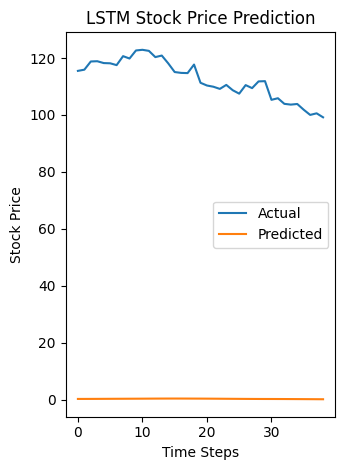

Mean Absolute Error: 112.23


In [22]:
# 6. Plot the Results
plt.subplot(1, 2, 2)
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('LSTM Stock Price Prediction')
plt.legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error: {mae:.2f}")



In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***Answer the following questions. (You can type answers in a text cell)***
1.	What is the purpose of normalizing the 'Close' prices before feeding them into the LSTM model?
2.	What is the purpose of the Dropout layer in the LSTM model?
3.	In the plot showing actual vs predicted stock prices, what does it indicate if the predicted line closely follows the actual line?


1. It helps the LSTM model converge faster during training by putting all features on a similar scale.
It prevents certain features with larger numeric ranges from dominating the learning process.
LSTMs use activation functions like tanh and sigmoid that work best with inputs in the range of -1 to 1 or 0 to 1

2. Serves as a regularization technique that prevents overfitting by randomly "dropping out" (setting to zero) a fraction of neurons during training, forces the network to learn more robust features that aren't reliant on specific neurons, helps the model generalize better to unseen data by reducing co-adaptation of neurons

3. The model has learned the underlying patterns in the data effectively.
The model is making accurate predictions on the test data.
The chosen architecture, parameters, and training process were appropriate for this forecasting task.